In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

df = pd.read_csv('pre-processed dataset (3).csv')
print(df.columns.tolist())

['Unnamed: 0', 'country', 'date', 'agricultural_land%', 'forest_land%', 'land_area', 'avg_precipitation', 'trade_in_services%', 'control_of_corruption_estimate', 'control_of_corruption_std', 'access_to_electricity%', 'renewvable_energy_consumption%', 'electric_power_consumption', 'co2_emisions', 'other_greenhouse_emisions', 'inflation_annual%', 'real_interest_rate', 'research_and_development_expenditure%', 'central_goverment_debt%', 'tax_revenue%', 'expense%', 'goverment_effectiveness_estimate', 'goverment_effectiveness_std', 'individuals_using_internet%', 'military_expenditure%', 'gdp_current_us', 'political_stability_estimate', 'political_stability_std', 'rule_of_law_estimate', 'rule_of_law_std', 'regulatory_quality_estimate', 'regulatory_quality_std', 'government_expenditure_on_education%', 'government_health_expenditure%', 'multidimensional_poverty_headcount_ratio%', 'gini_index', 'birth_rate', 'death_rate', 'life_expectancy_at_birth', 'population', 'rural_population', 'voice_and_a

In [ ]:
invalid_keywords = [
    'INCOME', 'WORLD', 'EUROPE &', 'ASIA &', 'AFRICA',
    'ARAB', 'CARIBBEAN', 'IDA', 'IBRD', 'DIVIDEND',
    'UNION', 'AREA', 'OECD', 'STATES'
]

def is_real_country(name):
    # Exception: Save the United States from being filtered out
    if name == 'UNITED STATES':
        return True

    # Filter out everything else containing the invalid keywords
    return not any(keyword in name for keyword in invalid_keywords)

df = df[df['country'].apply(is_real_country)]

In [ ]:
print(df['country'].sample(20))

6006           GREENLAND
8270              KOSOVO
240              ALBANIA
12896        PUERTO RICO
7728             JAMAICA
3806             DENMARK
9668              MALAWI
4677            ESWATINI
7234               INDIA
9907                MALI
7482             IRELAND
9928               MALTA
6108             GRENADA
1453              BELIZE
5629         GAMBIA, THE
6920             ICELAND
11264        NETHERLANDS
7517         ISLE OF MAN
11716    NORTH MACEDONIA
7217               INDIA
Name: country, dtype: object


In [ ]:
info = ['country','date']

In [ ]:
economic_policy_debt = [
    'central_goverment_debt%',
    'tax_revenue%',
    'expense%',
    'inflation_annual%',
    'real_interest_rate'
]

In [ ]:
education = [
    'government_expenditure_on_education%',
    'Literacy rate, adult total (% of people ages 15 and above)',
    'Literacy rate, youth (ages 15-24), gender parity index (GPI)',
    'School enrollment, primary (% net)',
    'School enrollment, secondary (% net)',
    'School enrollment, tertiary (gross), gender parity index (GPI)'
]

In [ ]:
environment = [
    'agricultural_land%',
    'forest_land%',
    'avg_precipitation',
    'co2_emisions',
    'other_greenhouse_emisions',
    'renewvable_energy_consumption%'
]

In [ ]:
financial_sector = [
    'gini_index',
     'gdp_current_us',
]

In [ ]:
gender = [
    'literacy rate, youth (ages 15-24), gender parity index (gpi)',
    'school enrollment, tertiary (gross), gender parity index (gpi)'
]

In [ ]:
health = [
    'life_expectancy_at_birth',
    'birth_rate',
    'death_rate',
    'Mortality rate, infant (per 1,000 live births)',
    'Mortality rate, under-5 (per 1,000 live births)',
    'Government_health_expenditure%'
]

In [ ]:
infrastructure = [
    'access_to_electricity%',
    'electric_power_consumption',
    'individuals_using_internet%',
    'People using at least basic drinking water services (% of population)',
    'People using at least basic sanitation services (% of population)'
]

In [ ]:
poverty = [
    'multidimensional_poverty_headcount_ratio%',
    'unemployment with basic education (% of total labor force with basic education)'
]

In [ ]:
private_sector_trade = [
    'trade_in_services%',
    'Exports of goods and services (% of gdp)',
    'Imports of goods and services (% of gdp)',
    'research_and_development_expenditure%'
]

In [ ]:
public_sector = [
    'control_of_corruption_estimate',
    'control_of_corruption_std',
    'goverment_effectiveness_estimate',
    'goverment_effectiveness_std',
    'political_stability_estimate',
    'political_stability_std',
    'rule_of_law_estimate',
    'rule_of_law_std',
    'regulatory_quality_estimate',
    'regulatory_quality_std',
    'voice_and_accountability_estimate',
    'voice_and_accountability_std'
]

In [ ]:
social_protection_labor = [
    'Labor force participation rate for ages 15-24, total (%) (national estimate)',
    'rural_population'
]

In [ ]:
core_economy = [
    'gdp_current_us',
    'population',
    'population_density'
]

In [ ]:
special = [
    'intentional_homicides',
    'homicide_available'
]

In [ ]:
all_normalized_columns = ['info','economic_policy_debt','education','environment','financial_sector','gender','health','infrastructure','poverty','private_sector_trade','public_sector','social_protection_labor','core_economy','special']

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols] = (
    df.groupby('country')[numeric_cols]
      .transform(lambda x: x.fillna(x.mean()))
)

In [ ]:
def get_pca_weight(data, cols):
    cols = [c for c in cols if c in data.columns]

    subset = data[cols].copy()
    subset = subset.fillna(subset.mean())

    pca = PCA(n_components=1)
    pca.fit(subset)

    return pca.explained_variance_ratio_[0]  # THIS is your weight

In [ ]:
weights = {}

weights['economic_policy_debt'] = get_pca_weight(df, economic_policy_debt)
weights['education'] = get_pca_weight(df, education)
weights['environment'] = get_pca_weight(df, environment)
weights['financial_sector'] = get_pca_weight(df, financial_sector)
weights['gender'] = get_pca_weight(df, gender)
weights['health'] = get_pca_weight(df, health)
weights['infrastructure'] = get_pca_weight(df, infrastructure)
weights['poverty'] = get_pca_weight(df, poverty)
weights['private_sector_trade'] = get_pca_weight(df, private_sector_trade)
weights['public_sector'] = get_pca_weight(df, public_sector)
weights['social_protection_labor'] = get_pca_weight(df, social_protection_labor)
weights['core_economy'] = get_pca_weight(df, core_economy)
weights['special'] = get_pca_weight(df, special)

In [ ]:
weights_df = pd.DataFrame(list(weights.items()), columns=['category', 'weight'])

# Normalize weights (VERY IMPORTANT)
weights_df['normalized_weight'] = weights_df['weight'] / weights_df['weight'].sum()

# Rank
weights_df = weights_df.sort_values(by='normalized_weight', ascending=False)

print(weights_df)

                   category    weight  normalized_weight
1                 education  1.000000           0.096618
10  social_protection_labor  1.000000           0.096618
2               environment  1.000000           0.096618
0      economic_policy_debt  0.999143           0.096535
12                  special  0.844628           0.081606
4                    gender  0.810164           0.078277
9             public_sector  0.752716           0.072726
5                    health  0.748965           0.072364
6            infrastructure  0.721899           0.069748
11             core_economy  0.674756           0.065194
7                   poverty  0.662973           0.064055
3          financial_sector  0.579522           0.055992
8      private_sector_trade  0.555264           0.053649


In [ ]:
def get_pca_score(data, cols):
    cols = [c for c in cols if c in data.columns]

    subset = data[cols].copy()
    subset = subset.fillna(subset.mean())

    from sklearn.decomposition import PCA
    pca = PCA(n_components=1)
    return pca.fit_transform(subset).flatten()

In [ ]:
df_scores = df[['country', 'date']].copy()

df_scores['economic_policy_debt'] = get_pca_score(df, economic_policy_debt)
df_scores['education'] = get_pca_score(df, education)
df_scores['environment'] = get_pca_score(df, environment)
df_scores['financial_sector'] = get_pca_score(df, financial_sector)
df_scores['gender'] = get_pca_score(df, gender)
df_scores['health'] = get_pca_score(df, health)
df_scores['infrastructure'] = get_pca_score(df, infrastructure)
df_scores['poverty'] = get_pca_score(df, poverty)
df_scores['private_sector_trade'] = get_pca_score(df, private_sector_trade)
df_scores['public_sector'] = get_pca_score(df, public_sector)
df_scores['social_protection_labor'] = get_pca_score(df, social_protection_labor)
df_scores['core_economy'] = get_pca_score(df, core_economy)
df_scores['special'] = get_pca_score(df, special)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

category_cols = list(weights_df['category'])

df_scores[category_cols] = scaler.fit_transform(df_scores[category_cols])

In [ ]:
weights_dict = dict(zip(weights_df['category'], weights_df['normalized_weight']))

In [ ]:
df_scores['development_score'] = 0

for col in category_cols:
    df_scores['development_score'] += df_scores[col] * weights_dict[col]

In [ ]:
df_scores['development_score'] = (
    df_scores['development_score'] - df_scores['development_score'].min()
) / (
    df_scores['development_score'].max() - df_scores['development_score'].min()
)

In [ ]:
weights_sorted = weights_df.sort_values(by='normalized_weight', ascending=False)

for _, row in weights_sorted.iterrows():
    print(f"{row['category']}: {row['normalized_weight']:.4f}")

education: 0.0966
social_protection_labor: 0.0966
environment: 0.0966
economic_policy_debt: 0.0965
special: 0.0816
gender: 0.0783
public_sector: 0.0727
health: 0.0724
infrastructure: 0.0697
core_economy: 0.0652
poverty: 0.0641
financial_sector: 0.0560
private_sector_trade: 0.0536


In [ ]:
weights_sorted[['category', 'normalized_weight']].reset_index(drop=True)

,category,normalized_weight
0,education,0.096618
1,social_protection_labor,0.096618
2,environment,0.096618
3,economic_policy_debt,0.096535
4,special,0.081606
5,gender,0.078277
6,public_sector,0.072726
7,health,0.072364
8,infrastructure,0.069748
9,core_economy,0.065194


# **1. The "Metamorphosis" in Conflict Zones (Time-Series)**



In [ ]:
df_scores['date'] = pd.to_datetime(df_scores['date'])
df_scores = df_scores.sort_values(['country', 'date'])

In [ ]:
conflict_countries = ['AFGHANISTAN', 'SYRIAN ARAB REPUBLIC', 'YEMEN, REP.', 'UKRAINE']

In [ ]:
global_avg = (
    df_scores
    .groupby('date')['development_score']
    .mean()
    .reset_index()
)

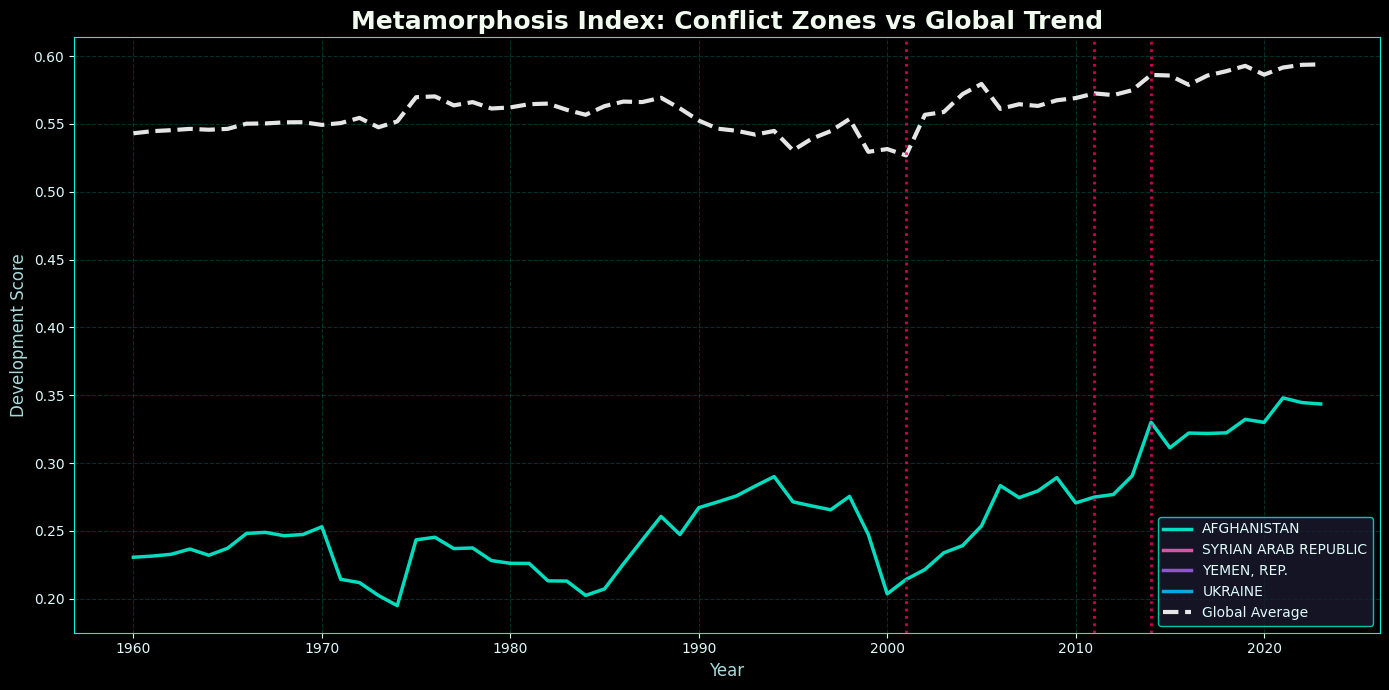

In [ ]:
import matplotlib.pyplot as plt

# Apply dark futuristic style
plt.style.use('dark_background')

plt.figure(figsize=(14,7))

# Neon color palette
colors = ['#00F5D4', '#F15BB5', '#9B5DE5', '#00BBF9', '#FEE440', '#FF6F61']

# Plot each conflict country
for i, country in enumerate(conflict_countries):
    temp = df_scores[df_scores['country'] == country]
    plt.plot(temp['date'], temp['development_score'],
             label=country,
             linewidth=2.5,
             color=colors[i % len(colors)],
             alpha=0.9)

# Plot global average (highlighted)
plt.plot(global_avg['date'], global_avg['development_score'],
         linestyle='--',
         linewidth=3,
         color='#FFFFFF',
         label='Global Average',
         alpha=0.9)

# Titles with glow feel
plt.title("Metamorphosis Index: Conflict Zones vs Global Trend",
          fontsize=18, color='#F1FAEE', weight='bold')
plt.xlabel("Year", fontsize=12, color='#A8DADC')
plt.ylabel("Development Score", fontsize=12, color='#A8DADC')

# Legend styling
legend = plt.legend(frameon=True, facecolor='#1a1a2e', edgecolor='#00F5D4', fontsize=10)
for text in legend.get_texts():
    text.set_color('#E0FBFC')

# Grid styling
plt.grid(True, linestyle='--', alpha=0.2, color='#00F5D4')

# Axis styling
plt.gca().spines['bottom'].set_color('#00F5D4')
plt.gca().spines['top'].set_color('#00F5D4')
plt.gca().spines['left'].set_color('#00F5D4')
plt.gca().spines['right'].set_color('#00F5D4')

plt.tick_params(colors='#E0FBFC')

# Conflict year markers (glowing accents)
plt.axvline(pd.to_datetime('2011'), linestyle=':', linewidth=2, color='#FF006E', alpha=0.8)
plt.axvline(pd.to_datetime('2014'), linestyle=':', linewidth=2, color='#FF006E', alpha=0.8)
plt.axvline(pd.to_datetime('2001'), linestyle=':', linewidth=2, color='#FF006E', alpha=0.8)

plt.tight_layout()
plt.show()

In [ ]:
unique_countries = sorted(df['country'].dropna().unique())

print("Total countries:", len(unique_countries))

for i, country in enumerate(unique_countries):
    print(f"{i+1}. {country}")

Total countries: 190
1. AFGHANISTAN
2. ALBANIA
3. ALGERIA
4. AMERICAN SAMOA
5. ANDORRA
6. ANGOLA
7. ANTIGUA AND BARBUDA
8. ARGENTINA
9. ARMENIA
10. ARUBA
11. AUSTRALIA
12. AUSTRIA
13. AZERBAIJAN
14. BAHAMAS, THE
15. BAHRAIN
16. BANGLADESH
17. BARBADOS
18. BELARUS
19. BELGIUM
20. BELIZE
21. BENIN
22. BERMUDA
23. BHUTAN
24. BOLIVIA
25. BOSNIA AND HERZEGOVINA
26. BOTSWANA
27. BRAZIL
28. BRITISH VIRGIN ISLANDS
29. BRUNEI DARUSSALAM
30. BULGARIA
31. BURKINA FASO
32. BURUNDI
33. CABO VERDE
34. CAMBODIA
35. CAMEROON
36. CANADA
37. CAYMAN ISLANDS
38. CENTRAL EUROPE AND THE BALTICS
39. CHAD
40. CHANNEL ISLANDS
41. CHILE
42. CHINA
43. COLOMBIA
44. COMOROS
45. CONGO, DEM. REP.
46. CONGO, REP.
47. COSTA RICA
48. COTE D'IVOIRE
49. CROATIA
50. CUBA
51. CURACAO
52. CYPRUS
53. CZECH REPUBLIC
54. CZECHIA
55. DENMARK
56. DJIBOUTI
57. DOMINICA
58. DOMINICAN REPUBLIC
59. ECUADOR
60. EL SALVADOR
61. EQUATORIAL GUINEA
62. ERITREA
63. ESTONIA
64. ESWATINI
65. ETHIOPIA
66. FAROE ISLANDS
67. FIJI
68. FINLAND
6

In [ ]:
region_map = {

#South Asia
'AFGHANISTAN':'South Asia','BANGLADESH':'South Asia','BHUTAN':'South Asia',
'INDIA':'South Asia','NEPAL':'South Asia','PAKISTAN':'South Asia',
'SRI LANKA':'South Asia',

#East Asia & Pacific
'CHINA':'East Asia','JAPAN':'East Asia','KOREA, REP.':'East Asia',
'KOREA, DEM. PEOPLE\'S REP.':'East Asia','MONGOLIA':'East Asia',
'VIETNAM':'East Asia','VIET NAM':'East Asia','THAILAND':'East Asia',
'INDONESIA':'East Asia','MALAYSIA':'East Asia','PHILIPPINES':'East Asia',
'SINGAPORE':'East Asia','LAO PDR':'East Asia','CAMBODIA':'East Asia',

# Europe
'GERMANY':'Europe','FRANCE':'Europe','ITALY':'Europe','SPAIN':'Europe',
'UNITED KINGDOM':'Europe','NETHERLANDS':'Europe','SWEDEN':'Europe',
'SWITZERLAND':'Europe','NORWAY':'Europe','DENMARK':'Europe',
'FINLAND':'Europe','BELGIUM':'Europe','AUSTRIA':'Europe','POLAND':'Europe',
'CZECH REPUBLIC':'Europe','CZECHIA':'Europe','HUNGARY':'Europe',
'PORTUGAL':'Europe','GREECE':'Europe','ROMANIA':'Europe','BULGARIA':'Europe',

# Middle East & North Africa
'IRAN, ISLAMIC REP.':'Middle East','IRAQ':'Middle East','ISRAEL':'Middle East',
'JORDAN':'Middle East','KUWAIT':'Middle East','OMAN':'Middle East',
'QATAR':'Middle East','SAUDI ARABIA':'Middle East',
'UNITED ARAB EMIRATES':'Middle East','YEMEN, REP.':'Middle East',
'SYRIAN ARAB REPUBLIC':'Middle East','EGYPT, ARAB REP.':'Middle East',
'MOROCCO':'Middle East','TUNISIA':'Middle East','LIBYA':'Middle East',

# Sub-Saharan Africa
'NIGERIA':'Africa','KENYA':'Africa','ETHIOPIA':'Africa','GHANA':'Africa',
'TANZANIA':'Africa','UGANDA':'Africa','SOUTH AFRICA':'Africa',
'ZAMBIA':'Africa','ZIMBABWE':'Africa','SENEGAL':'Africa','MALI':'Africa',
'BURKINA FASO':'Africa','NIGER':'Africa','RWANDA':'Africa','SUDAN':'Africa',

# Latin America
'BRAZIL':'Latin America','ARGENTINA':'Latin America','MEXICO':'Latin America',
'CHILE':'Latin America','COLOMBIA':'Latin America','PERU':'Latin America',
'VENEZUELA, RB':'Latin America','ECUADOR':'Latin America','PARAGUAY':'Latin America',

# North America
'UNITED STATES':'North America','CANADA':'North America',

# Oceania
'AUSTRALIA':'Oceania','NEW ZEALAND':'Oceania','FIJI':'Oceania'
}

In [ ]:
df['region'] = df['country'].map(region_map)

In [ ]:
cols = ['region'] + [col for col in df.columns if col != 'region']
df = df[cols]

In [ ]:
print(cols)

['region', 'Unnamed: 0', 'country', 'date', 'agricultural_land%', 'forest_land%', 'land_area', 'avg_precipitation', 'trade_in_services%', 'control_of_corruption_estimate', 'control_of_corruption_std', 'access_to_electricity%', 'renewvable_energy_consumption%', 'electric_power_consumption', 'co2_emisions', 'other_greenhouse_emisions', 'inflation_annual%', 'real_interest_rate', 'research_and_development_expenditure%', 'central_goverment_debt%', 'tax_revenue%', 'expense%', 'goverment_effectiveness_estimate', 'goverment_effectiveness_std', 'individuals_using_internet%', 'military_expenditure%', 'gdp_current_us', 'political_stability_estimate', 'political_stability_std', 'rule_of_law_estimate', 'rule_of_law_std', 'regulatory_quality_estimate', 'regulatory_quality_std', 'government_expenditure_on_education%', 'government_health_expenditure%', 'multidimensional_poverty_headcount_ratio%', 'gini_index', 'birth_rate', 'death_rate', 'life_expectancy_at_birth', 'population', 'rural_population', 'v

# **2. The Race to Exponential Growth (Trend Analysis)**


In [ ]:
df_scores['date'] = pd.to_datetime(df_scores['date'])
df_scores['country'] = df_scores['country'].str.upper().str.strip()

# Adding region
df_scores['region'] = df_scores['country'].map(region_map)

In [ ]:
df_scores = df_scores[df_scores['date'].dt.year >= 2000]

In [ ]:
region_trend = (
    df_scores
    .groupby(['region', 'date'])['development_score']
    .mean()
    .reset_index()
)

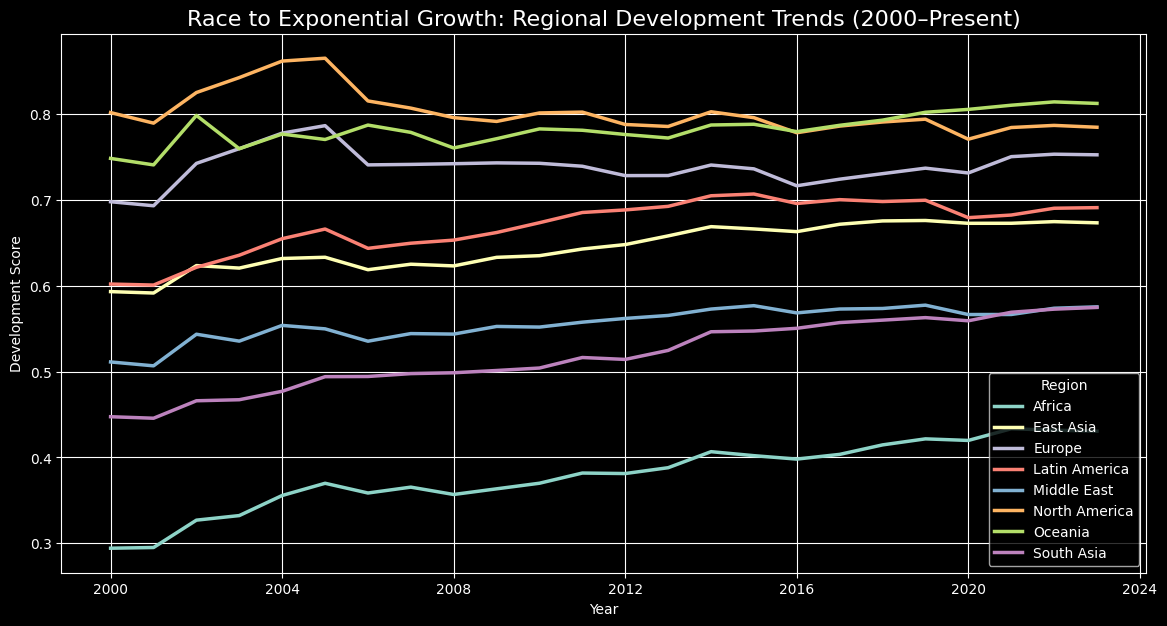

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

sns.lineplot(
    data=region_trend,
    x='date',
    y='development_score',
    hue='region',
    linewidth=2.5
)

plt.title("Race to Exponential Growth: Regional Development Trends (2000–Present)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Development Score")

plt.legend(title='Region')
plt.grid(True)

plt.show()

# **3. The Citizen-Government Synergy (Correlation)**

In [ ]:
df_plot = df_scores.copy()
#removing missing values
df_plot = df_plot[['public_sector', 'social_protection_labor']].dropna()

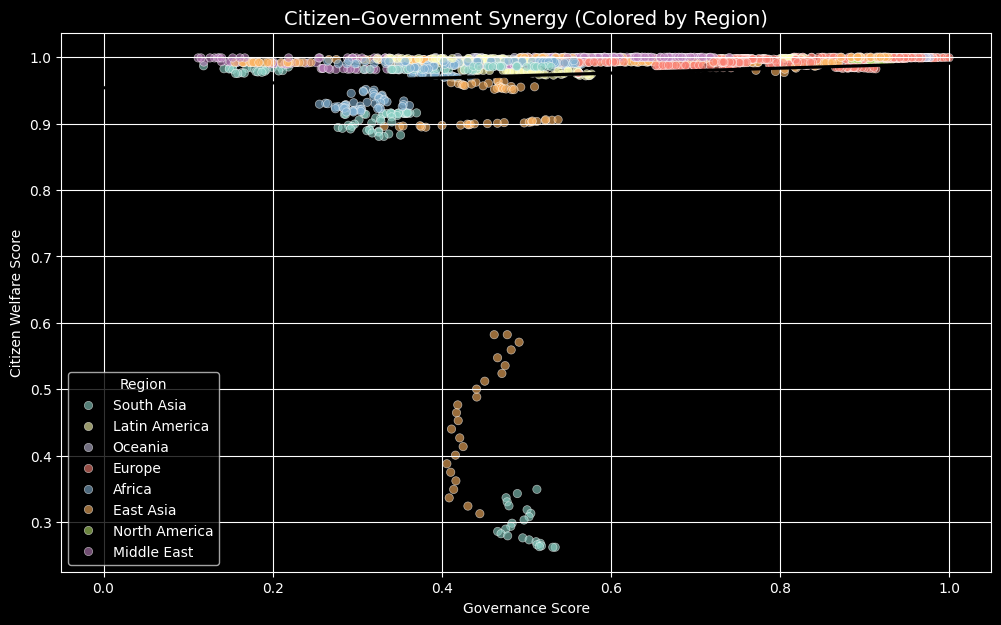

In [ ]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df_scores,
    x='public_sector',
    y='social_protection_labor',
    hue='region',
    alpha=0.6
)

# Add regression line separately
sns.regplot(
    data=df_scores,
    x='public_sector',
    y='social_protection_labor',
    scatter=False,
    color='black'
)

plt.title("Citizen–Government Synergy (Colored by Region)", fontsize=14)
plt.xlabel("Governance Score")
plt.ylabel("Citizen Welfare Score")

plt.legend(title='Region')
plt.grid(True)

plt.show()

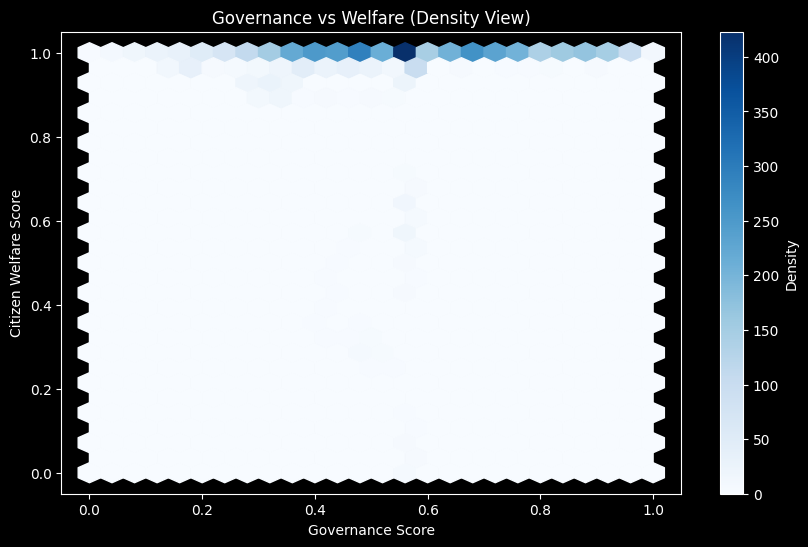

In [ ]:
plt.figure(figsize=(10,6))

plt.hexbin(
    df_scores['public_sector'],
    df_scores['social_protection_labor'],
    gridsize=25,
    cmap='Blues'
)

plt.colorbar(label='Density')
plt.xlabel("Governance Score")
plt.ylabel("Citizen Welfare Score")
plt.title("Governance vs Welfare (Density View)")

plt.show()

# **4. The Pillar Champions (Categorical Leaders)**

In [ ]:
latest_year = df_scores['date'].max()

df_latest = df_scores[df_scores['date'] == latest_year]

In [ ]:
categories = [
    'environment',
    'infrastructure',
    'health',
    'education',
    'core_economy',
    'public_sector'
]

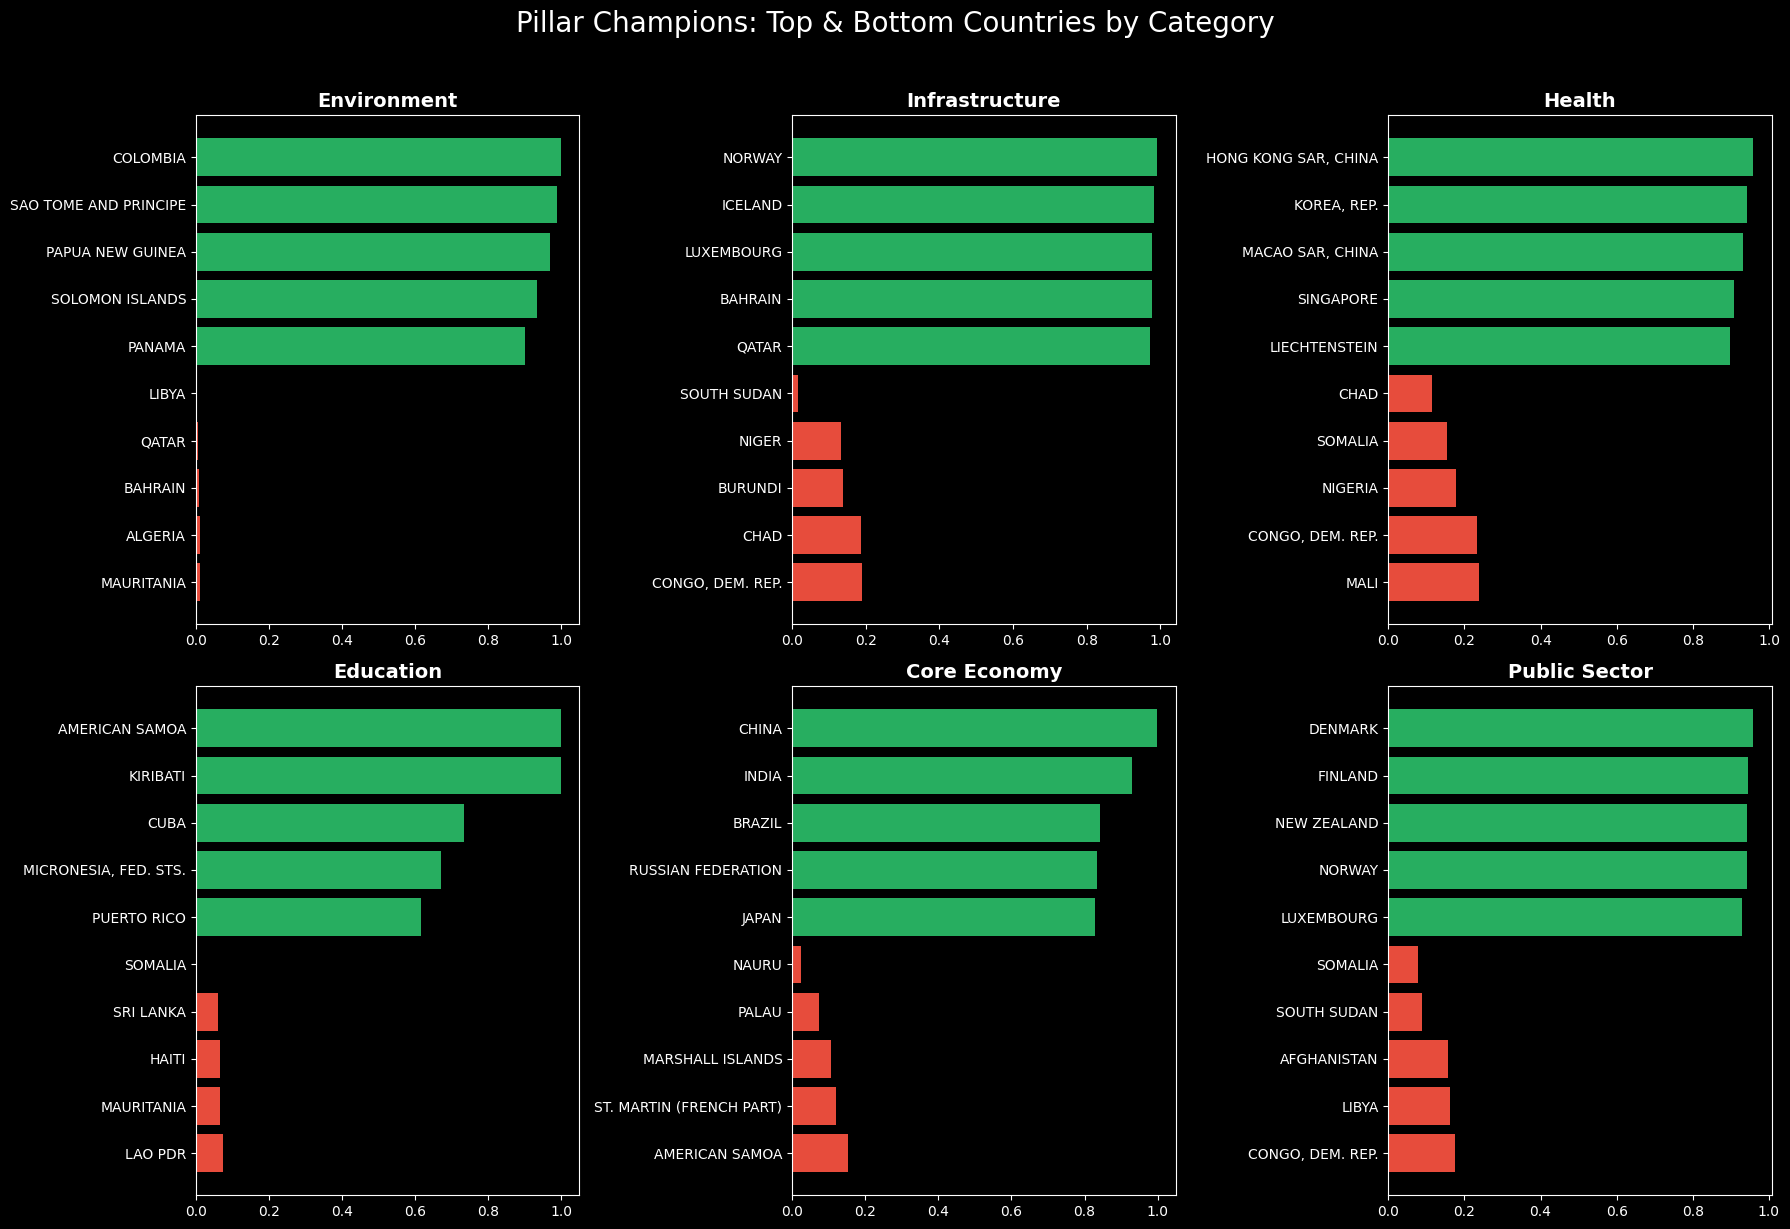

In [ ]:
regions_to_exclude = [
    "Africa Eastern and Southern", "Africa Western and Central", "Arab World",
    "Caribbean small states", "Central Europe and the Baltics", "Early-demographic dividend",
    "East Asia & Pacific", "East Asia & Pacific (excluding high income)",
    "East Asia & Pacific (IDA & IBRD countries)", "Euro area", "Europe & Central Asia",
    "Europe & Central Asia (excluding high income)", "Europe & Central Asia (IDA & IBRD countries)",
    "European Union", "Fragile and conflict affected situations", "Heavily indebted poor countries (HIPC)",
    "High income", "IBRD only", "IDA & IBRD total", "IDA blend", "IDA only", "IDA total",
    "Late-demographic dividend", "Latin America & Caribbean",
    "Latin America & Caribbean (excluding high income)", "Latin America & the Caribbean (IDA & IBRD countries)",
    "Least developed countries: UN classification", "Low & middle income", "Low income",
    "Lower middle income", "Middle East & North Africa", "Middle East & North Africa (excluding high income)",
    "Middle East & North Africa (IDA & IBRD countries)", "Middle income", "North America",
    "OECD members", "Other small states", "Pacific island small states", "Post-demographic dividend",
    "Pre-demographic dividend", "Small states", "South Asia", "South Asia (IDA & IBRD)",
    "Sub-Saharan Africa", "Sub-Saharan Africa (excluding high income)",
    "Sub-Saharan Africa (IDA & IBRD countries)", "Upper middle income", "World"
]

df_countries = df_latest[~df_latest['country'].str.upper().isin([r.upper() for r in regions_to_exclude])]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()
colors = ['#27ae60'] * 5 + ['#e74c3c'] * 5

for i, col in enumerate(categories):
    ax = axes[i]
    df_clean = df_countries.dropna(subset=[col])

    top5 = df_clean.nlargest(5, col)[['country', col]]
    bottom5 = df_clean.nsmallest(5, col)[['country', col]]
    combined = pd.concat([top5, bottom5])

    ax.barh(combined['country'], combined[col], color=colors)
    ax.set_title(f"{col.replace('_',' ').title()}", fontsize=14, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle("Pillar Champions: Top & Bottom Countries by Category", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

##**5. Regional Disparities in Overall Development**

In [ ]:
latest_year = df_scores['date'].max()
df_latest = df_scores[df_scores['date'] == latest_year].copy()

# ensure region exists
df_latest['region'] = df_latest['country'].map(region_map)

In [ ]:
# drop missing
df_latest = df_latest.dropna(subset=['region', 'development_score'])

# order regions by median (makes plot much clearer)
region_order = (
    df_latest.groupby('region')['development_score']
    .median()
    .sort_values(ascending=False)
    .index
)

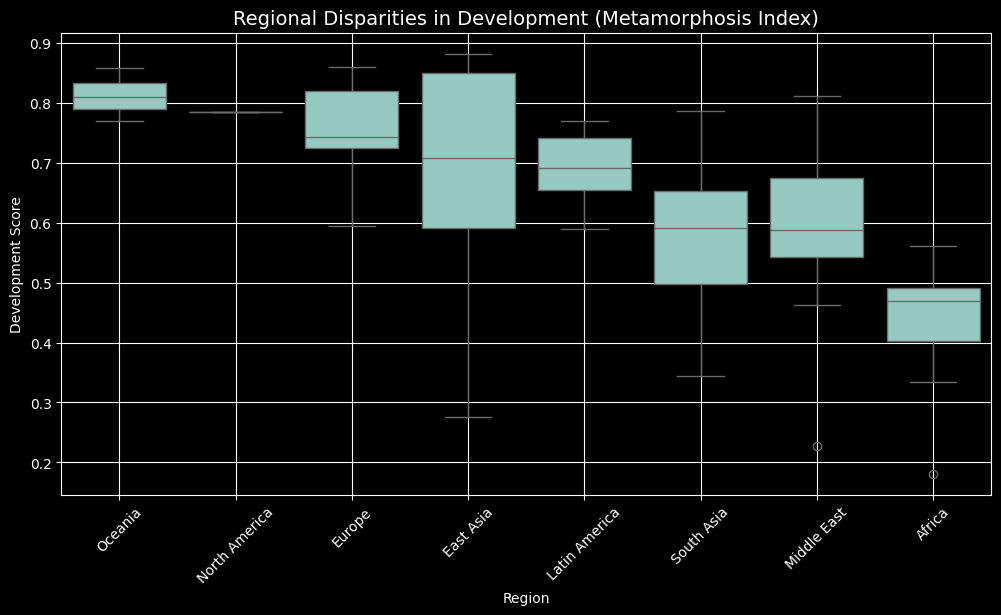

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_latest,
    x='region',
    y='development_score',
    order=region_order
)

plt.title("Regional Disparities in Development (Metamorphosis Index)", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Development Score")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

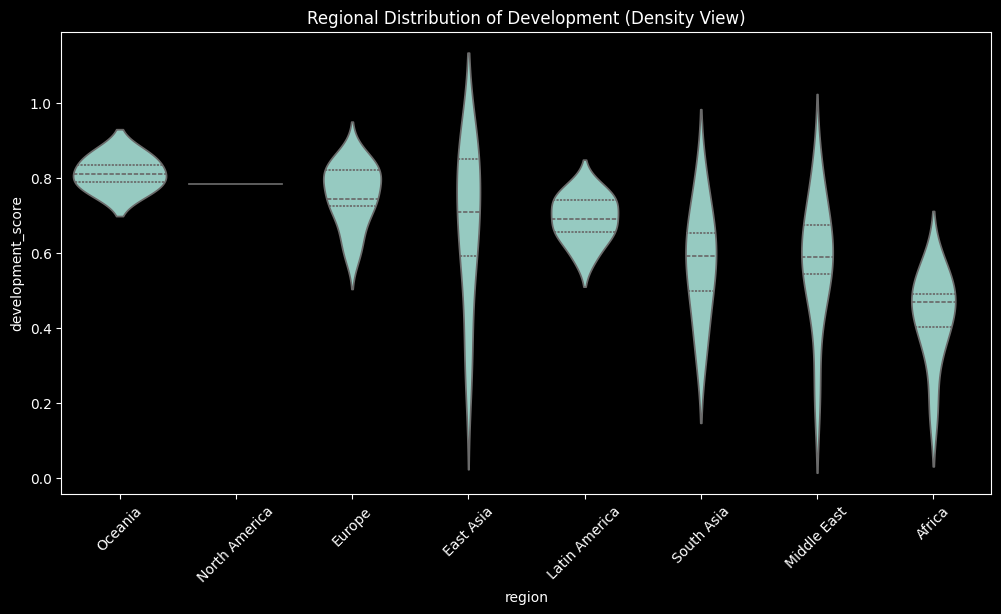

In [ ]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_latest,
    x='region',
    y='development_score',
    order=region_order,
    inner='quartile'
)

plt.title("Regional Distribution of Development (Density View)")
plt.xticks(rotation=45)

plt.show()

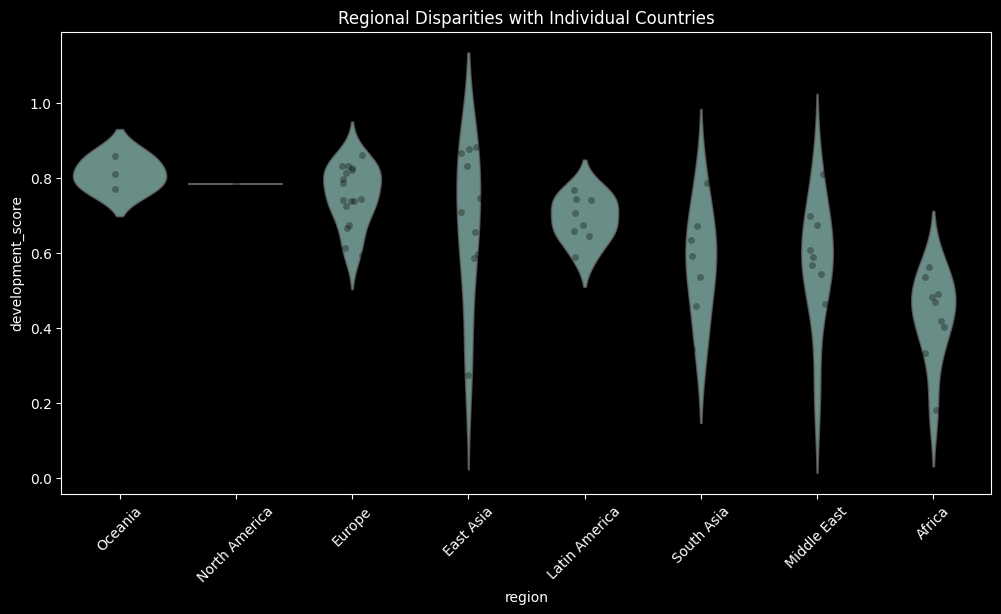

In [ ]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_latest,
    x='region',
    y='development_score',
    order=region_order,
    inner=None,
    alpha=0.7
)

sns.stripplot(
    data=df_latest,
    x='region',
    y='development_score',
    order=region_order,
    color='black',
    alpha=0.3
)

plt.title("Regional Disparities with Individual Countries")
plt.xticks(rotation=45)

plt.show()

# **6. The Wealth Paradox: GDP vs. Metamorphosis (Scatter)**

In [ ]:
df_plot = df.copy()

In [ ]:
print([col for col in df_plot.columns if 'gdp' in col.lower()])
print([col for col in df_plot.columns if 'pop' in col.lower()])

['gdp_current_us', 'exports of goods and services (% of gdp)', 'imports of goods and services (% of gdp)']
['population', 'rural_population', 'people using at least basic drinking water services (% of population)', 'people using at least basic sanitation services (% of population)', 'population_density']


In [ ]:
df_plot = df_plot[(df_plot['gdp_current_us'] > 0) & (df_plot['population'] > 0)]

df_plot['gdp_per_capita'] = df_plot['gdp_current_us'] / df_plot['population']

In [ ]:
df_plot['log_gdp_pc'] = np.log(df_plot['gdp_per_capita'])

In [ ]:
df_plot['date'] = pd.to_datetime(df_plot['date'], errors='coerce')
df_scores['date'] = pd.to_datetime(df_scores['date'], errors='coerce')

In [ ]:
df_plot = df_plot.merge(
    df_scores[['country', 'date', 'development_score']],
    on=['country', 'date'],
    how='left'
)

In [ ]:
latest_year = df_plot['date'].max()
df_plot = df_plot[df_plot['date'] == latest_year]

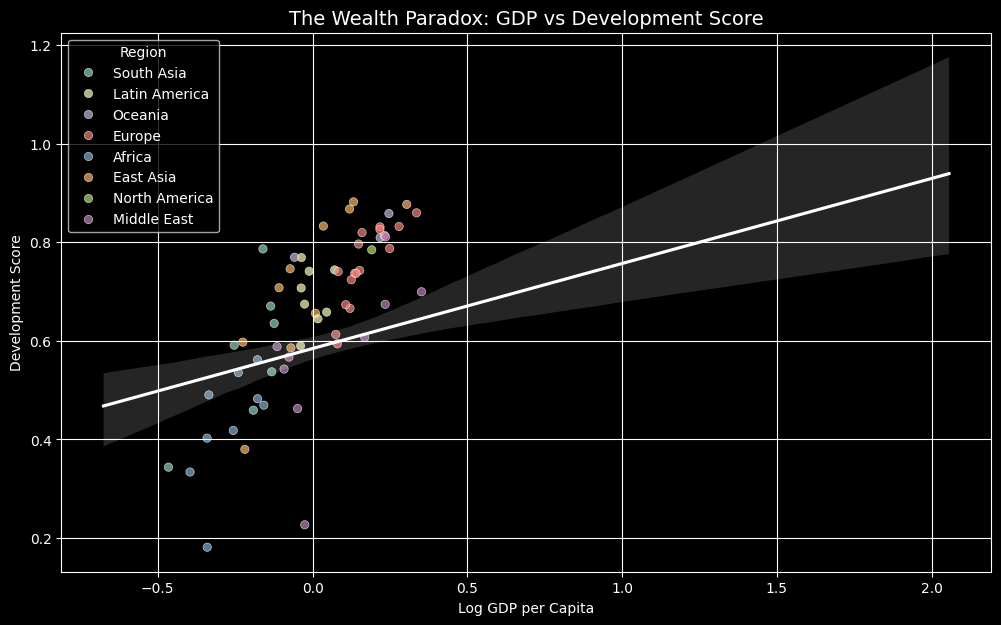

In [ ]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df_plot,
    x='log_gdp_pc',
    y='development_score',
    hue='region',
    alpha=0.7
)
sns.regplot(
    data=df_plot,
    x='log_gdp_pc',
    y='development_score',
    scatter=False,
    color='white'
)


plt.title("The Wealth Paradox: GDP vs Development Score", fontsize=14)
plt.xlabel("Log GDP per Capita")
plt.ylabel("Development Score")

plt.grid(True)
plt.legend(title='Region')

plt.show()

# **7. The Environmental Cost of Development (Trade-offs)**

In [ ]:
country_name = 'INDIA'   # or 'CHINA'

In [ ]:
df_country = df_scores[df_scores['country'] == country_name].copy()

# Ensure date is datetime
df_country['date'] = pd.to_datetime(df_country['date'])

# Sort
df_country = df_country.sort_values('date')

In [ ]:
print(df_country[['date', 'core_economy', 'environment']].head())

           date  core_economy  environment
7237 2000-01-01      0.899290      0.32255
7238 2001-01-01      0.900746      0.32255
7239 2002-01-01      0.900079      0.32255
7240 2003-01-01      0.901911      0.32255
7241 2004-01-01      0.902836      0.32255


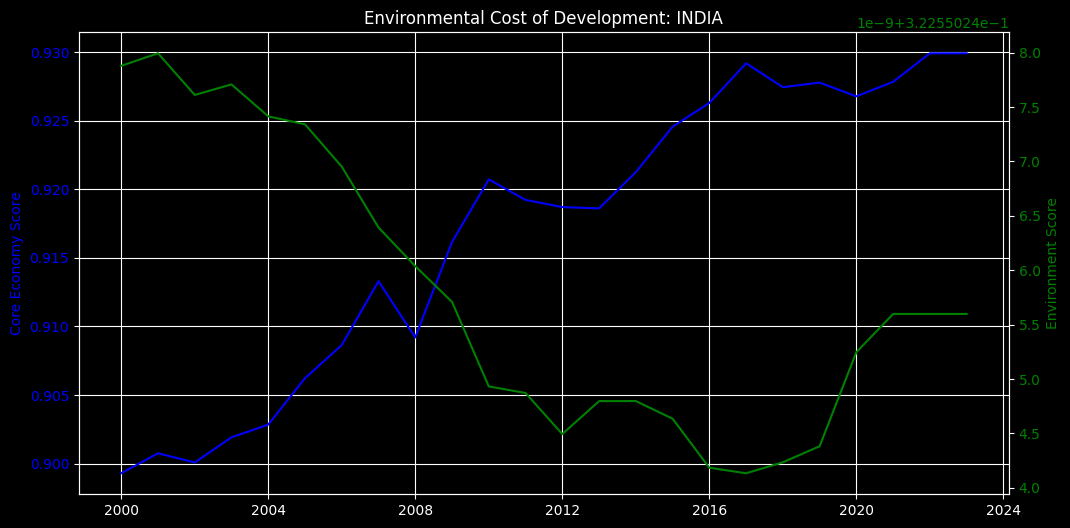

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Core economy (LEFT axis)
ax1.plot(
    df_country['date'],
    df_country['core_economy'],
    color='blue',
    label='Core Economy'
)
ax1.set_ylabel('Core Economy Score', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Second axis
ax2 = ax1.twinx()

# Environment (RIGHT axis)
ax2.plot(
    df_country['date'],
    df_country['environment'],
    color='green',
    label='Environment'
)
ax2.set_ylabel('Environment Score', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Title
plt.title(f'Environmental Cost of Development: {country_name}')

# Grid
ax1.grid(True)

plt.show()

# **8. The Metamorphosis Anatomy: How Much Does Each Pillar Matter?**

In [ ]:
weights_plot = weights_df.sort_values(by='normalized_weight', ascending=False)

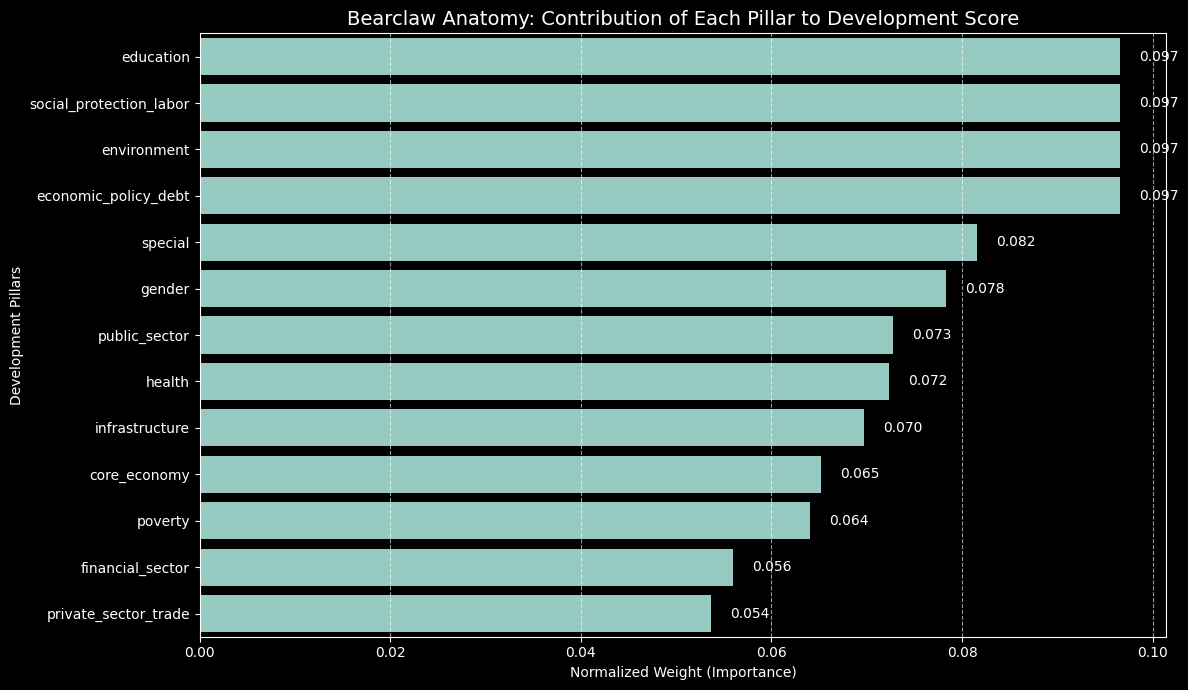

In [ ]:

# Step 1: Sort weights
weights_plot = weights_df.sort_values(by='normalized_weight', ascending=False)

# Step 2: Create figure
plt.figure(figsize=(12,7))

# Step 3: Bar plot (horizontal for clarity)
sns.barplot(
    data=weights_plot,
    x='normalized_weight',
    y='category'
)

# Step 4: Add value labels
for i, v in enumerate(weights_plot['normalized_weight']):
    plt.text(v + 0.002, i, f"{v:.3f}", va='center')

# Step 5: Styling
plt.title('Bearclaw Anatomy: Contribution of Each Pillar to Development Score', fontsize=14)
plt.xlabel('Normalized Weight (Importance)')
plt.ylabel('Development Pillars')

plt.grid(axis='x', linestyle='--', alpha=0.6)

# Step 6: Clean layout
plt.tight_layout()

# Step 7: Show
plt.show()

# **9. The Category Interlocking Matrix (Heatmap)**

In [ ]:
category_cols = [
    'economic_policy_debt',
    'education',
    'environment',
    'financial_sector',
    'gender',
    'health',
    'infrastructure',
    'poverty',
    'private_sector_trade',
    'public_sector',
    'social_protection_labor',
    'core_economy',
    'special'
]

In [ ]:
corr_matrix = df_scores[category_cols].corr()

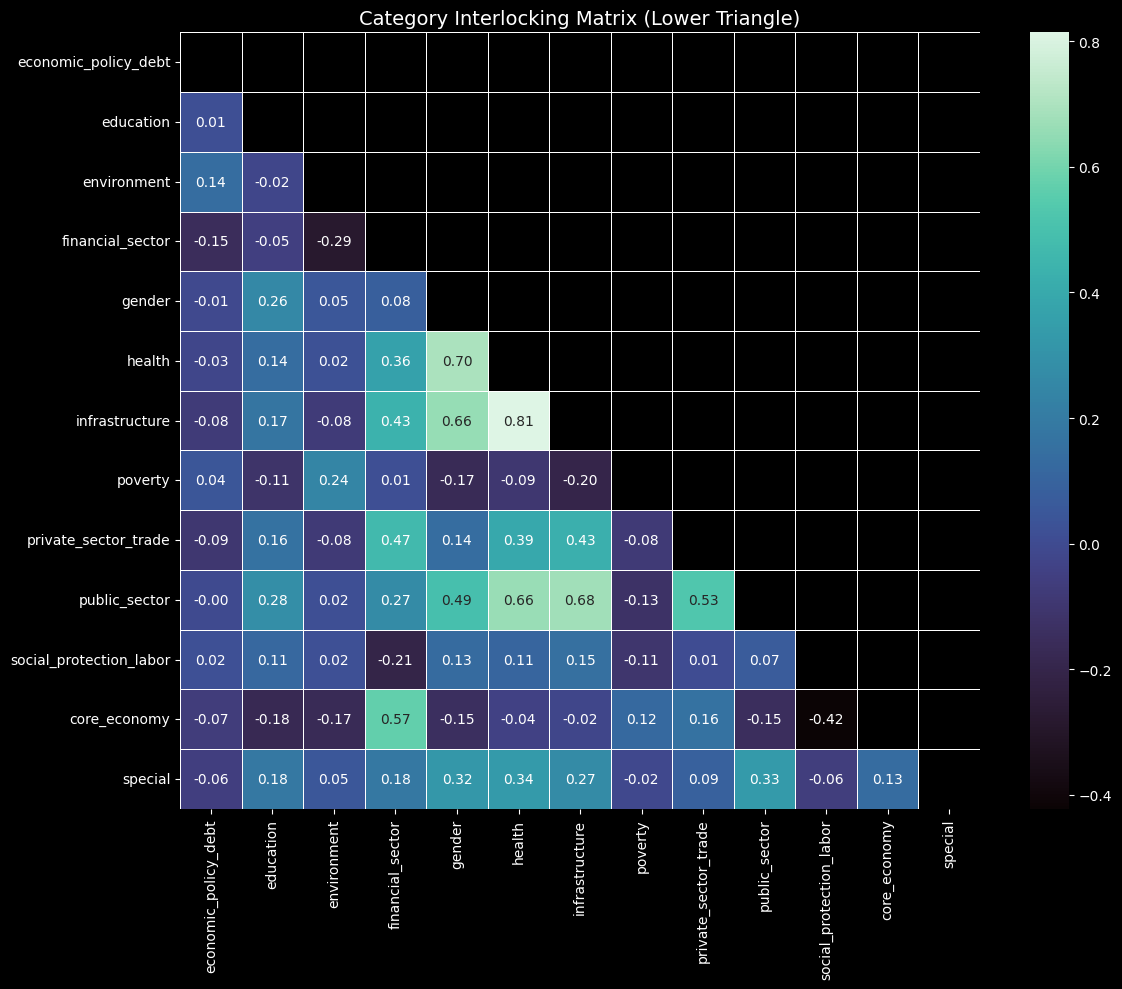

In [ ]:
import numpy as np

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='mako',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Category Interlocking Matrix (Lower Triangle)', fontsize=14)

plt.tight_layout()
plt.show()

# **10. The Data Shadow: Completeness vs. Region (Meta-Analysis)**

In [ ]:
df_raw = pd.read_csv('final_enriched_dataset (1).csv')
df_raw.columns = df_raw.columns.str.strip().str.lower()
# Ensure clean country + region
df_raw['country'] = df_raw['country'].str.upper().str.strip()
df_raw['region'] = df_raw['country'].map(region_map)

# Remove rows without region
df_raw = df_raw.dropna(subset=['region'])

In [ ]:
region_missing = (
    df_raw
    .groupby('region')
    .apply(lambda x: x.isnull().mean() * 100)
)

/tmp/ipykernel_2071/924547875.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean() * 100)


In [ ]:
top_missing_cols = (
    df_raw.isnull().mean()
    .sort_values(ascending=False)
    .head(20)
    .index
)

region_missing_top = region_missing[top_missing_cols]

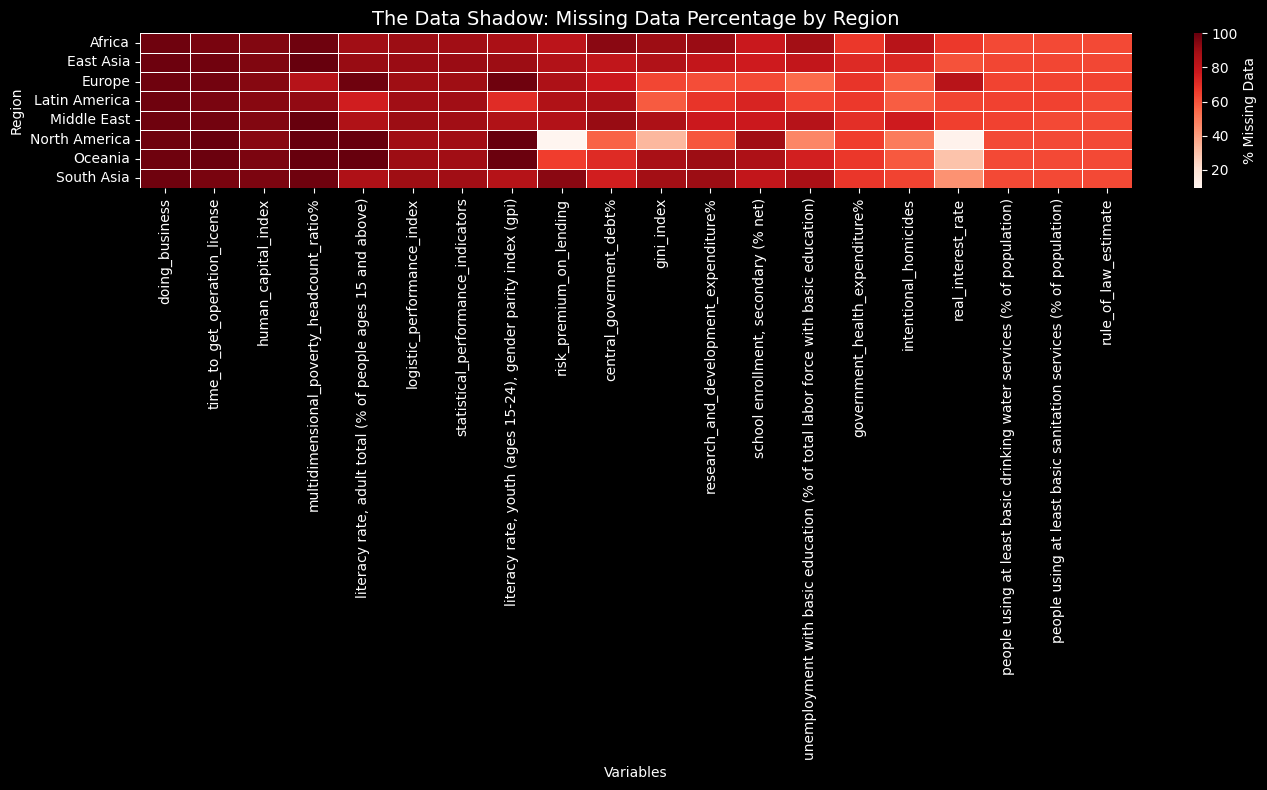

In [ ]:
plt.figure(figsize=(14,8))

sns.heatmap(
    region_missing_top,
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': '% Missing Data'}
)

plt.title("The Data Shadow: Missing Data Percentage by Region", fontsize=14)
plt.xlabel("Variables")
plt.ylabel("Region")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2071/3638692154.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean().mean() * 100)
/tmp/ipykernel_2071/3638692154.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


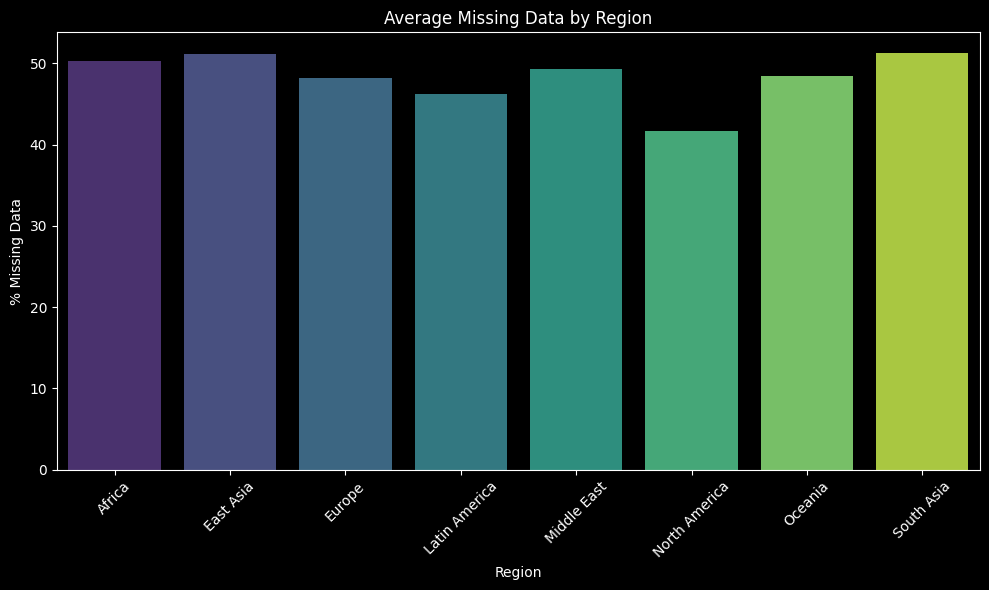

In [ ]:
region_avg_missing = (
    df_raw
    .groupby('region')
    .apply(lambda x: x.isnull().mean().mean() * 100)
    .reset_index(name='avg_missing')
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=region_avg_missing,
    x='region',
    y='avg_missing',
    palette = 'viridis'

)

plt.title("Average Missing Data by Region")
plt.ylabel("% Missing Data")
plt.xlabel("Region")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# The Blended Metamorphosis Weights (Expert + PCA, summing to ~1.0)
blended_weights = {
    'education': 0.096558,
    'social_protection_labor': 0.096558,
    'environment': 0.096558,
    'economic_policy_debt': 0.096477,
    'special': 0.081178,
    'gender': 0.076846,
    'public_sector': 0.072930,
    'health': 0.071961,
    'infrastructure': 0.069034,
    'core_economy': 0.066109,
    'poverty': 0.064899,
    'private_sector_trade': 0.055722,
    'financial_sector': 0.055171
}

# 1. Initialize the final score column
# (Keeping the name 'development_score' so it automatically hooks into all 10 of your plot scripts)
df_scores['development_score'] = 0

# 2. Multiply each normalized category score by its blended weight and sum it up
for col, weight in blended_weights.items():
    df_scores['development_score'] += df_scores[col] * weight

# 3. Normalize the final index to a 0-100 scale for presentation clarity
min_score = df_scores['development_score'].min()
max_score = df_scores['development_score'].max()
df_scores['development_score'] = ((df_scores['development_score'] - min_score) / (max_score - min_score)) * 100

# Let's peek at the final attachment to ensure it worked flawlessly
print("--- LATEST SCORES BY COUNTRY ---")
latest_year = df_scores['date'].max()
print(df_scores[df_scores['date'] == latest_year][['country', 'date', 'development_score']]
      .sort_values('development_score', ascending=False)
      .head(70))

--- LATEST SCORES BY COUNTRY ---
           country       date  development_score
6940       ICELAND 2023-01-01          91.888653
8220   KOREA, REP. 2023-01-01          88.381642
13786    SINGAPORE 2023-01-01          87.680300
7836         JAPAN 2023-01-01          86.782638
11866       NORWAY 2023-01-01          85.828409
...            ...        ...                ...
447        ANDORRA 2023-01-01          66.307153
14682    ST. LUCIA 2023-01-01          66.088394
6428        GUYANA 2023-01-01          65.969651
4477   EL SALVADOR 2023-01-01          65.844051
3934      DOMINICA 2023-01-01          65.771402

[70 rows x 3 columns]


In [ ]:
# Calculate the Holistic Metamorphosis Score (All-Time Average per Country)
holistic_scores = (
    df_scores.groupby('country')['development_score']
    .mean()
    .reset_index()
    .sort_values('development_score', ascending=False)
)

print("--- HOLISTIC METAMORPHOSIS SCORE (ALL YEARS AVERAGE) ---")
print(holistic_scores.head(15))

# If you want to see the bottom 10 holistically:
print("\n--- BOTTOM 10 HOLISTICALLY ---")
print(holistic_scores.tail(10))

--- HOLISTIC METAMORPHOSIS SCORE (ALL YEARS AVERAGE) ---
           country  development_score
90         ICELAND          93.081941
151         NORWAY          90.598039
175      SINGAPORE          88.622689
54         DENMARK          87.454303
100          JAPAN          87.425164
106    KOREA, REP.          85.480956
123       MALAYSIA          84.811727
11         AUSTRIA          83.699107
148  NORTH AMERICA          83.661307
144    NEW ZEALAND          83.610777
142    NETHERLANDS          82.837905
67         FINLAND          82.696921
18         BELGIUM          81.644744
74         GERMANY          81.603310
10       AUSTRALIA          80.819074

--- BOTTOM 10 HOLISTICALLY ---
              country  development_score
47      COTE D'IVOIRE          23.599396
43            COMOROS          19.781681
45        CONGO, REP.          18.639789
82             GUINEA          18.041123
44   CONGO, DEM. REP.          15.906647
72        GAMBIA, THE          14.917755
125             

--- HOLISTIC AVERAGE SCORES ---
CHINA: 58.02
INDIA: 48.07
PAKISTAN: 45.19


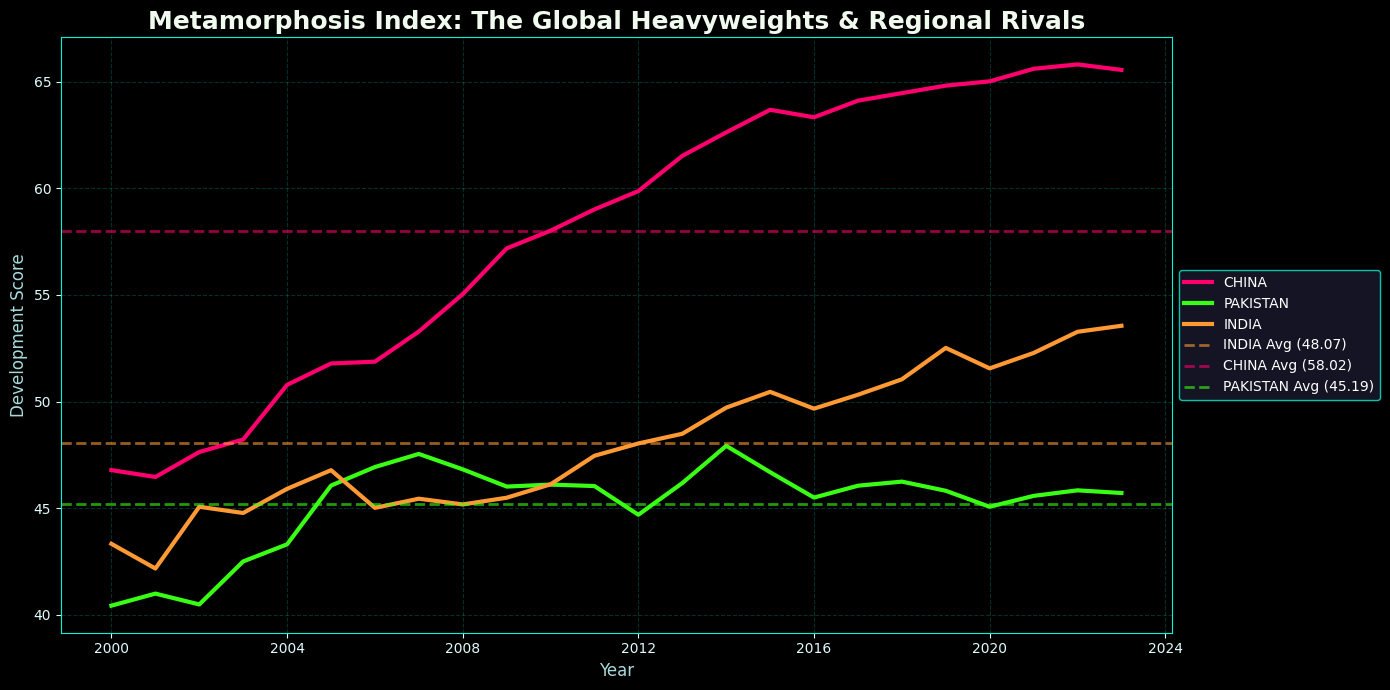

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Isolate data for India, China, and Pakistan
target_countries = ['INDIA', 'CHINA', 'PAKISTAN']
compare_data = df_scores[df_scores['country'].isin(target_countries)].copy()
compare_data['date'] = pd.to_datetime(compare_data['date'])
compare_data = compare_data.sort_values('date')

# 2. Calculate the holistic (all-time) averages
averages = compare_data.groupby('country')['development_score'].mean()

print("--- HOLISTIC AVERAGE SCORES ---")
for country, avg in averages.items():
    print(f"{country}: {avg:.2f}")

# 3. Visualize the Trends vs. Averages
plt.figure(figsize=(14, 7))

# Set dark background to match your previous presentation style
plt.style.use('dark_background')

# Define a distinct neon color palette for all FOUR countries
color_map = {
    'INDIA': '#FF9933',         # Saffron/Orange
    'CHINA': '#FF006E',         # Neon Red/Pink
    'UNITED STATES': '#3A86FF', # Neon Blue
    'PAKISTAN': '#39FF14'       # Neon Green
}

# Plot the actual year-by-year trends
sns.lineplot(
    data=compare_data,
    x='date',
    y='development_score',
    hue='country',
    palette=color_map,
    linewidth=3
)

# Plot the flat average lines
for country in target_countries:
    plt.axhline(
        averages[country],
        color=color_map[country],
        linestyle='--',
        linewidth=2,
        alpha=0.6,
        label=f'{country} Avg ({averages[country]:.2f})'
    )

# Styling
plt.title("Metamorphosis Index: The Global Heavyweights & Regional Rivals", fontsize=18, weight='bold', color='#F1FAEE')
plt.xlabel("Year", fontsize=12, color='#A8DADC')
plt.ylabel("Development Score", fontsize=12, color='#A8DADC')

# Move legend outside the plot area
plt.legend(
    frameon=True,
    facecolor='#1a1a2e',
    edgecolor='#00F5D4',
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.grid(True, linestyle='--', alpha=0.2, color='#00F5D4')

# Clean up axes
plt.gca().spines['bottom'].set_color('#00F5D4')
plt.gca().spines['top'].set_color('#00F5D4')
plt.gca().spines['left'].set_color('#00F5D4')
plt.gca().spines['right'].set_color('#00F5D4')
plt.tick_params(colors='#E0FBFC')

plt.tight_layout()
plt.show()

--- K-MEANS CLUSTER BENCHMARKS (CENTERS) ---
Tier 4: Fragile / Vulnerable: ~22.2 Score
Tier 3: Emerging: ~42.5 Score
Tier 2: Accelerating: ~61.5 Score
Tier 1: Advanced Metamorphosis: ~77.2 Score

--- COUNTRY TIER EXAMPLES ---
                                        country  development_score  \
1663                                     BHUTAN          78.477957   
12762                                  PORTUGAL          73.582692   
383                              AMERICAN SAMOA          71.400997   
6428                                     GUYANA          65.969651   
1599                                    BERMUDA          65.114230   
9275                                  LITHUANIA          64.045304   
6172                                       GUAM          62.276856   
12442                          PAPUA NEW GUINEA          56.065727   
14746                  ST. MARTIN (FRENCH PART)          54.633163   
9083                                    LIBERIA          49.408375   
5404

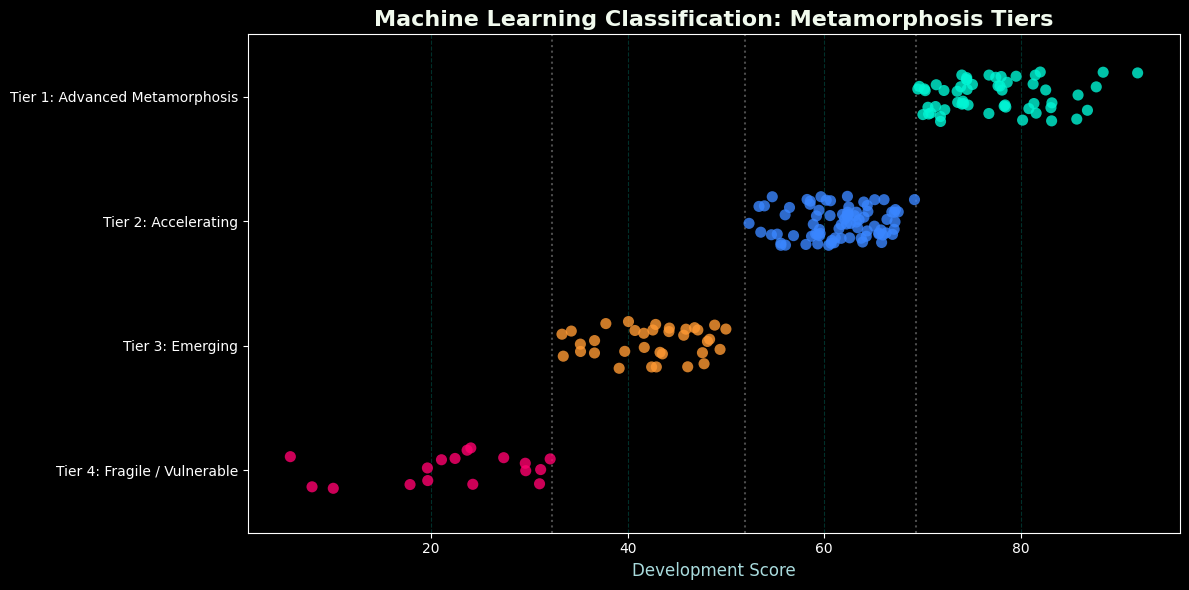

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Isolate the latest year's data for our current global classification
latest_year = df_scores['date'].max()
df_latest = df_scores[df_scores['date'] == latest_year].copy()

# Drop any potential NaNs just in case
df_latest = df_latest.dropna(subset=['development_score'])

# 2. Prepare the data for Scikit-Learn
X = df_latest[['development_score']]

# 3. Run K-Means Clustering (Asking for 4 distinct tiers)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_latest['cluster'] = kmeans.fit_predict(X)

# 4. Map the random cluster numbers to our ordered Tiers
# K-Means assigns cluster numbers randomly. We need to sort them by their center values
# so that the lowest score always gets "Tier 4" and the highest gets "Tier 1".
centers = kmeans.cluster_centers_.flatten()
sorted_idx = np.argsort(centers) # Gets the original cluster indices ordered from lowest to highest center

# Create our modern nomenclature mapping
tier_names = [
    "Tier 4: Fragile / Vulnerable",
    "Tier 3: Emerging",
    "Tier 2: Accelerating",
    "Tier 1: Advanced Metamorphosis"
]

# Map the sorted indices to the names
cluster_to_tier = {sorted_idx[i]: tier_names[i] for i in range(4)}
df_latest['metamorphosis_tier'] = df_latest['cluster'].map(cluster_to_tier)

# --- LET'S SEE THE RESULTS ---
print("--- K-MEANS CLUSTER BENCHMARKS (CENTERS) ---")
for i in range(4):
    print(f"{tier_names[i]}: ~{centers[sorted_idx[i]]:.1f} Score")

print("\n--- COUNTRY TIER EXAMPLES ---")
print(df_latest[['country', 'development_score', 'metamorphosis_tier']].sample(15).sort_values('development_score', ascending=False))


# --- VISUALIZE THE ALGORITHM'S DECISIONS ---
plt.figure(figsize=(12, 6))
plt.style.use('dark_background')

# Define tier colors (Red/Orange for vulnerable, Blue/Green for advanced)
tier_palette = {
    "Tier 1: Advanced Metamorphosis": "#00F5D4", # Neon Green/Cyan
    "Tier 2: Accelerating": "#3A86FF",           # Neon Blue
    "Tier 3: Emerging": "#FF9933",               # Orange
    "Tier 4: Fragile / Vulnerable": "#FF006E"    # Neon Pink/Red
}

# Create a strip plot to show every single country as a dot in its tier
# Create a strip plot to show every single country as a dot in its tier
sns.stripplot(
    data=df_latest,
    x='development_score',
    y='metamorphosis_tier',
    hue='metamorphosis_tier',
    palette=tier_palette,
    order=tier_names[::-1], # <--- THE FIX: Proper list reversal
    jitter=0.2,
    size=8,
    alpha=0.8,
    legend=False
)

plt.title("Machine Learning Classification: Metamorphosis Tiers", fontsize=16, weight='bold', color='#F1FAEE')
plt.xlabel("Development Score", fontsize=12, color='#A8DADC')
plt.ylabel("")

# Add faint dashed lines at the cluster midpoints to show the ML boundaries
for i in range(3):
    midpoint = (centers[sorted_idx[i]] + centers[sorted_idx[i+1]]) / 2
    plt.axvline(x=midpoint, color='#FFFFFF', linestyle=':', alpha=0.3)

plt.grid(True, axis='x', linestyle='--', alpha=0.2, color='#00F5D4')
plt.tight_layout()
plt.show()

--- HOLISTIC K-MEANS CLUSTER BENCHMARKS (CENTERS) ---
Tier 4: Fragile / Vulnerable: ~20.4 Average Score
Tier 3: Emerging: ~41.5 Average Score
Tier 2: Accelerating: ~61.4 Average Score
Tier 1: Advanced Metamorphosis: ~77.6 Average Score

--- COUNTRY TIER EXAMPLES (HOLISTIC) ---
                  country  development_score              metamorphosis_tier
175             SINGAPORE          88.622689  Tier 1: Advanced Metamorphosis
35                 CANADA          80.102761  Tier 1: Advanced Metamorphosis
88   HONG KONG SAR, CHINA          76.823806  Tier 1: Advanced Metamorphosis
98                  ITALY          74.065320  Tier 1: Advanced Metamorphosis
26                 BRAZIL          73.702526  Tier 1: Advanced Metamorphosis
129             MAURITIUS          70.699545  Tier 1: Advanced Metamorphosis
9                   ARUBA          69.353143            Tier 2: Accelerating
50                CURACAO          62.504455            Tier 2: Accelerating
73                GEORGIA    

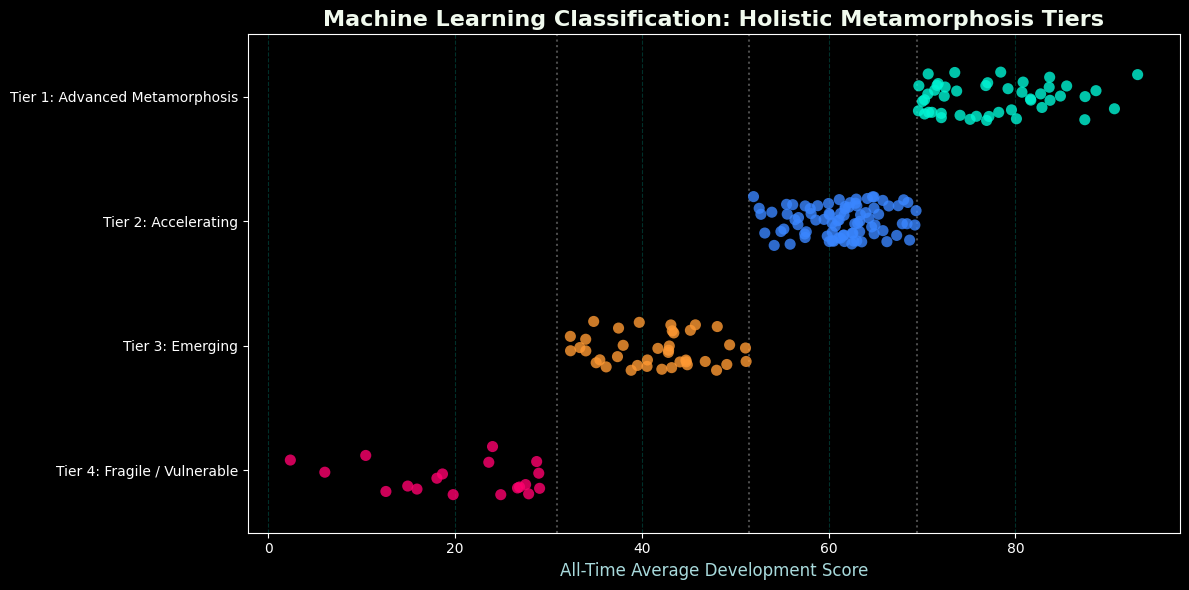

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate the holistic average development score for each country across all years
df_holistic = df_scores.groupby('country')['development_score'].mean().reset_index()

# Drop any potential NaNs just in case
df_holistic = df_holistic.dropna(subset=['development_score'])

# 2. Prepare the data for Scikit-Learn
X = df_holistic[['development_score']]

# 3. Run K-Means Clustering (Asking for 4 distinct tiers)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_holistic['cluster'] = kmeans.fit_predict(X)

# 4. Map the random cluster numbers to our ordered Tiers
centers = kmeans.cluster_centers_.flatten()
sorted_idx = np.argsort(centers)

# Create our modern nomenclature mapping
tier_names = [
    "Tier 4: Fragile / Vulnerable",
    "Tier 3: Emerging",
    "Tier 2: Accelerating",
    "Tier 1: Advanced Metamorphosis"
]

# Map the sorted indices to the names
cluster_to_tier = {sorted_idx[i]: tier_names[i] for i in range(4)}
df_holistic['metamorphosis_tier'] = df_holistic['cluster'].map(cluster_to_tier)

# --- LET'S SEE THE RESULTS ---
print("--- HOLISTIC K-MEANS CLUSTER BENCHMARKS (CENTERS) ---")
for i in range(4):
    print(f"{tier_names[i]}: ~{centers[sorted_idx[i]]:.1f} Average Score")

print("\n--- COUNTRY TIER EXAMPLES (HOLISTIC) ---")
# Sample 15 random countries to see where they landed historically
print(df_holistic[['country', 'development_score', 'metamorphosis_tier']].sample(15).sort_values('development_score', ascending=False))


# --- VISUALIZE THE ALGORITHM'S DECISIONS ---
plt.figure(figsize=(12, 6))
plt.style.use('dark_background')

# Define tier colors
tier_palette = {
    "Tier 1: Advanced Metamorphosis": "#00F5D4", # Neon Green/Cyan
    "Tier 2: Accelerating": "#3A86FF",           # Neon Blue
    "Tier 3: Emerging": "#FF9933",               # Orange
    "Tier 4: Fragile / Vulnerable": "#FF006E"    # Neon Pink/Red
}

# Create a strip plot
sns.stripplot(
    data=df_holistic,
    x='development_score',
    y='metamorphosis_tier',
    hue='metamorphosis_tier',
    palette=tier_palette,
    order=tier_names[::-1],
    jitter=0.2,
    size=8,
    alpha=0.8,
    legend=False
)

plt.title("Machine Learning Classification: Holistic Metamorphosis Tiers", fontsize=16, weight='bold', color='#F1FAEE')
plt.xlabel("All-Time Average Development Score", fontsize=12, color='#A8DADC')
plt.ylabel("")

# Add faint dashed lines at the cluster midpoints to show the ML boundaries
for i in range(3):
    midpoint = (centers[sorted_idx[i]] + centers[sorted_idx[i+1]]) / 2
    plt.axvline(x=midpoint, color='#FFFFFF', linestyle=':', alpha=0.3)

plt.grid(True, axis='x', linestyle='--', alpha=0.2, color='#00F5D4')
plt.tight_layout()
plt.show()

In [ ]:
!pip install prophet

In [ ]:
import prophet
print(f"Prophet version {prophet.__version__} successfully installed and ready to forecast!")

Prophet version 1.3.0 successfully installed and ready to forecast!


INFO:prophet:n_changepoints greater than number of observations. Using 18.


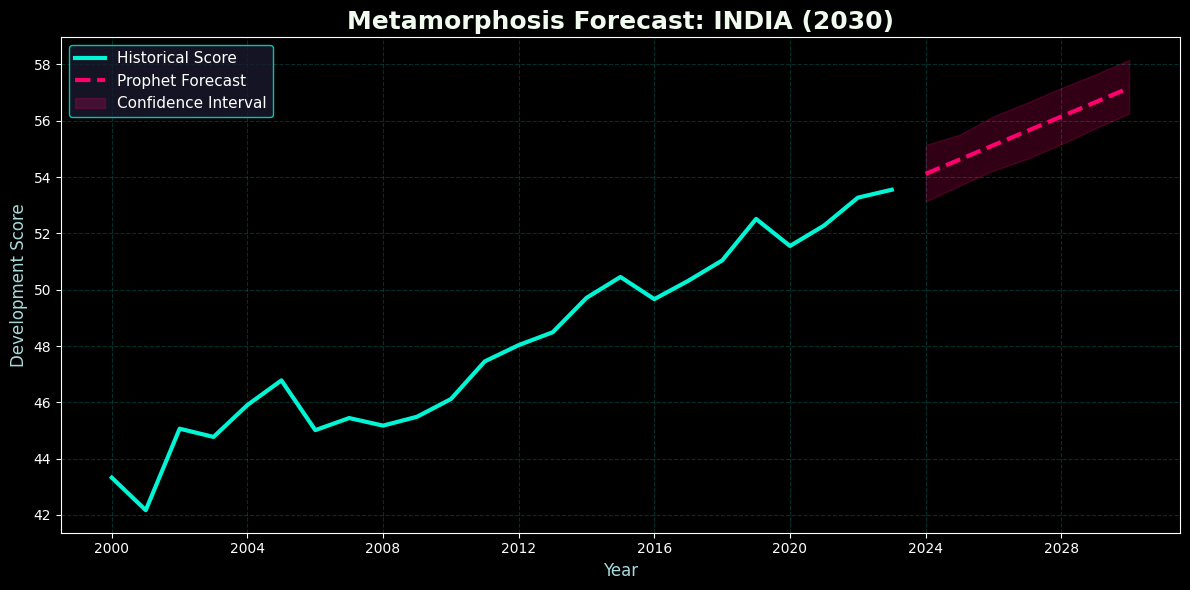

=== INDIA METAMORPHOSIS FORECAST (2030) ===
Projected Score:  57.2
Worst/Best Case:  56.3  <--->  58.2
Projected Status: Tier 2: Accelerating



In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def predict_metamorphosis(df, target_country, target_year=2030):
    # ---------------------------------------------------------
    # STEP 1: DATA PREP (The Prophet Translation)
    # ---------------------------------------------------------
    # Isolate country and rename columns to 'ds' and 'y' as Prophet demands
    history = df[df['country'] == target_country][['date', 'development_score']].copy()
    history = history.rename(columns={'date': 'ds', 'development_score': 'y'})
    history['ds'] = pd.to_datetime(history['ds'])
    history = history.sort_values('ds')

    # Calculate how many years into the future we need to project
    current_year = history['ds'].dt.year.max()
    years_to_predict = target_year - current_year

    if years_to_predict <= 0:
        return "Target year must be in the future!"

    # ---------------------------------------------------------
    # STEP 2 & 3: TRAIN & FORECAST (The Engine)
    # ---------------------------------------------------------
    # Initialize Prophet (turning off daily/weekly seasonality for yearly data)
    model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    model.fit(history)

    # Create the future timeline and predict
    # 'YS' means Year Start frequency (Jan 1st)
    future = model.make_future_dataframe(periods=years_to_predict, freq='YS')
    forecast = model.predict(future)

    # Extract the final prediction for the target year
    final_prediction = forecast.iloc[-1]
    predicted_score = final_prediction['yhat']
    worst_case = final_prediction['yhat_lower']
    best_case = final_prediction['yhat_upper']

    # ---------------------------------------------------------
    # STEP 4: THE LABEL MAPPING (Using K-Means Boundaries)
    # ---------------------------------------------------------
    def get_tier(score):
        # These are the exact mathematical midpoints between your K-Means clusters
        if score >= 68.95: return "Tier 1: Advanced Metamorphosis"
        elif score >= 51.55: return "Tier 2: Accelerating"
        elif score >= 32.30: return "Tier 3: Emerging"
        else: return "Tier 4: Fragile / Vulnerable"

    future_tier = get_tier(predicted_score)

    # ---------------------------------------------------------
    # STEP 5: VISUALIZATION (The Presentation Chart)
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 6))
    plt.style.use('dark_background')

    # Plot historical actuals
    plt.plot(history['ds'], history['y'], color='#00F5D4', linewidth=3, label=f'Historical Score')

    # Plot future prediction
    future_dates = forecast['ds'][forecast['ds'].dt.year > current_year]
    future_scores = forecast['yhat'][forecast['ds'].dt.year > current_year]
    plt.plot(future_dates, future_scores, color='#FF006E', linestyle='--', linewidth=3, label='Prophet Forecast')

    # Add the Confidence Interval ("Cone of Uncertainty")
    plt.fill_between(
        future_dates,
        forecast['yhat_lower'][forecast['ds'].dt.year > current_year],
        forecast['yhat_upper'][forecast['ds'].dt.year > current_year],
        color='#FF006E', alpha=0.2, label='Confidence Interval'
    )

    # Styling
    plt.title(f"Metamorphosis Forecast: {target_country} ({target_year})", fontsize=18, weight='bold', color='#F1FAEE')
    plt.xlabel("Year", fontsize=12, color='#A8DADC')
    plt.ylabel("Development Score", fontsize=12, color='#A8DADC')
    plt.legend(frameon=True, facecolor='#1a1a2e', edgecolor='#00F5D4', fontsize=11, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.2, color='#00F5D4')

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # TERMINAL REPORT
    # ---------------------------------------------------------
    print(f"=== {target_country.upper()} METAMORPHOSIS FORECAST ({target_year}) ===")
    print(f"Projected Score:  {predicted_score:.1f}")
    print(f"Worst/Best Case:  {worst_case:.1f}  <--->  {best_case:.1f}")
    print(f"Projected Status: {future_tier}")
    print("==================================================\n")

# --- LET'S TEST IT OUT! ---
# You can change the country and the year here to predict anyone's future.
predict_metamorphosis(df_scores, target_country='INDIA', target_year=2030)

INFO:prophet:n_changepoints greater than number of observations. Using 18.


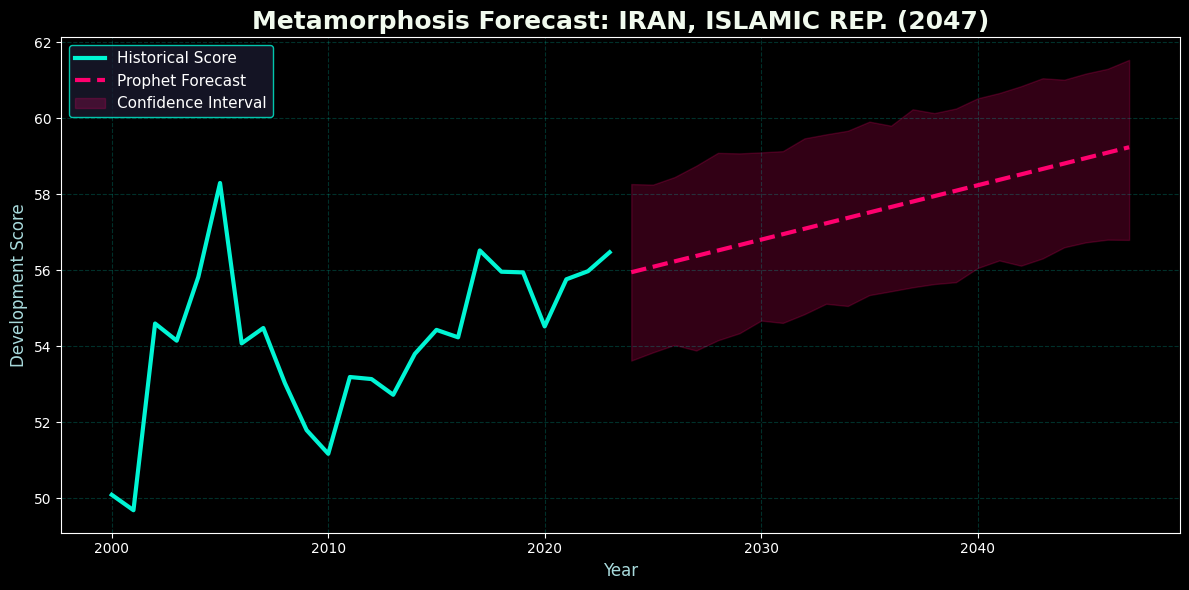

=== IRAN, ISLAMIC REP. METAMORPHOSIS FORECAST (2047) ===
Projected Score:  59.2
Worst/Best Case:  56.8  <--->  61.5
Projected Status: Tier 2: Accelerating



In [ ]:
predict_metamorphosis(df_scores, target_country='IRAN, ISLAMIC REP.', target_year=2047)

INFO:prophet:n_changepoints greater than number of observations. Using 18.


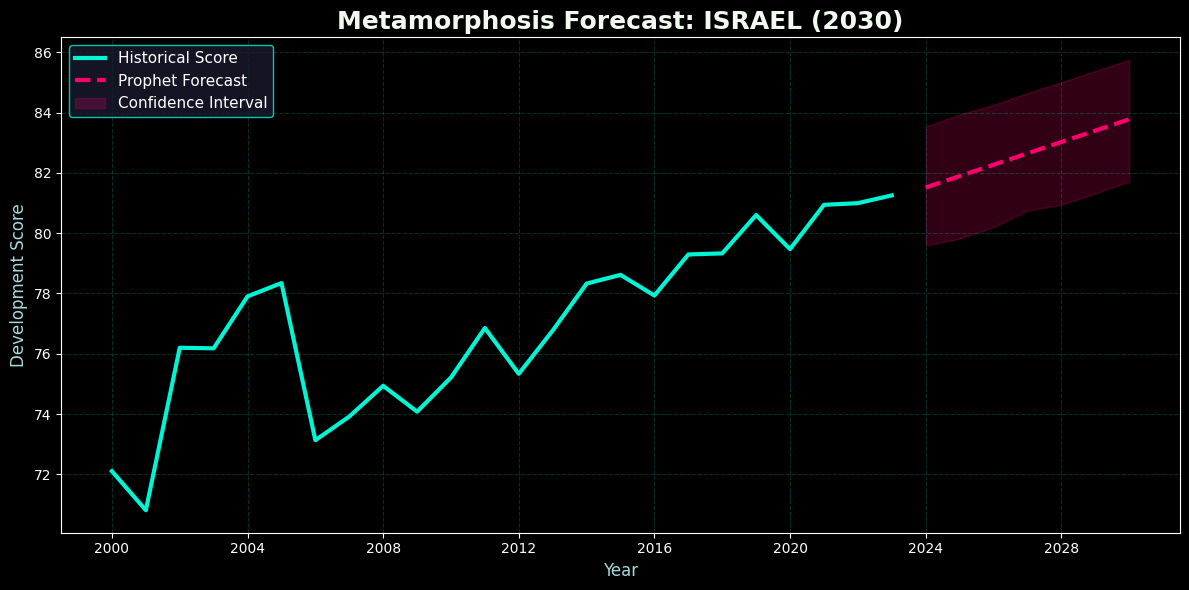

=== ISRAEL METAMORPHOSIS FORECAST (2030) ===
Projected Score:  83.8
Worst/Best Case:  81.7  <--->  85.8
Projected Status: Tier 1: Advanced Metamorphosis



In [ ]:
predict_metamorphosis(df_scores, target_country='ISRAEL', target_year=2030)

INFO:prophet:n_changepoints greater than number of observations. Using 18.


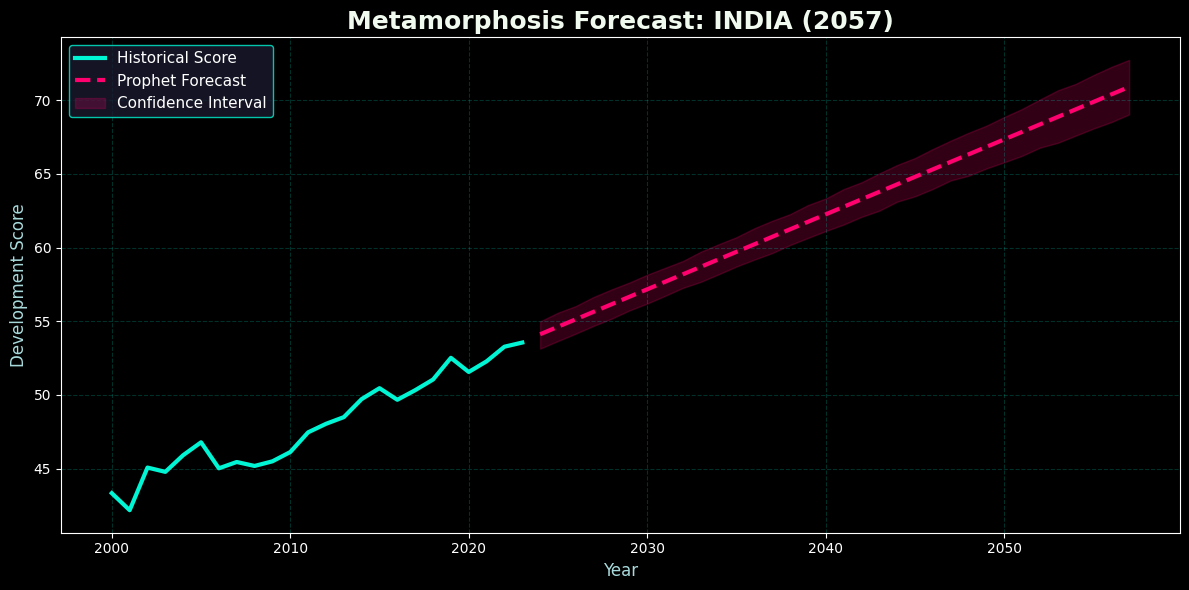

=== INDIA METAMORPHOSIS FORECAST (2057) ===
Projected Score:  70.9
Worst/Best Case:  69.0  <--->  72.7
Projected Status: Tier 1: Advanced Metamorphosis



In [ ]:
predict_metamorphosis(df_scores, target_country='INDIA', target_year=2057)